In [11]:
import numpy as np
from scipy.integrate import solve_ivp, odeint
import matplotlib.pyplot as plt


The needed datas

In [12]:
D = np.array([0.05, 0.10, 0.20, 0.40, 0.60, 0.70, 0.80, 0.84], dtype=float)
X = np.array([3.2, 3.7, 4.0, 4.4, 4.75, 4.9, 4.5, 0.5], dtype=float)
S = np.array([0.012, 0.028, 0.050, 0.100, 0.150, 0.176, 0.800, 9.0], dtype=float)

S0 = 10.0  # g/L

Exercice 4a)

At steady state in a chemostat:

$$
\mu = D
$$

Assuming Monod kinetics:

$$
\mu = \mu_{\max} \frac{S}{K_s + S}
$$

Thus:

$$
D = \mu_{\max} \frac{S}{K_s + S}
$$

Linearizing (Lineweaver–Burk form):

$$
\frac{1}{D} = \frac{K_s}{\mu_{\max}} \frac{1}{S} + \frac{1}{\mu_{\max}}
$$

This allows estimation of $\mu_{\max}$ and $K_s$ using linear regression.

Part (a)
mu_max = 2.2982 h^-1
Ks     = 0.5482 g/L


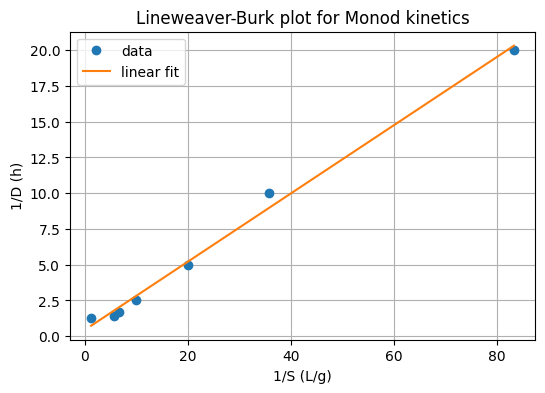

In [13]:
D_fit = D[:7]
S_fit = S[:7]

x_LB = 1 / S_fit
y_LB = 1 / D_fit

slope, intercept = np.polyfit(x_LB, y_LB, 1)
mu_max = 1 / intercept
Ks = slope * mu_max

print("Part (a)")
print(f"mu_max = {mu_max:.4f} h^-1")
print(f"Ks     = {Ks:.4f} g/L")

plt.figure(figsize=(6, 4))
plt.plot(1 / S_fit, 1 / D_fit, 'o', label='data')
plt.plot(1 / S_fit, slope * (1 / S_fit) + intercept, '-', label='linear fit')
plt.xlabel('1/S (L/g)')
plt.ylabel('1/D (h)')
plt.title('Lineweaver-Burk plot for Monod kinetics')
plt.legend()
plt.grid(True)


Exercice 4b)

At steady state, the substrate balance is:

$$
D(S_0 - S) = r_S
$$

Including maintenance:

$$
r_S = \frac{r_X}{Y_{X/S}} + mX
$$

Since $r_X = \mu X = D X$:

$$
D(S_0 - S) = \frac{D X}{Y_{X/S}} + m X
$$

Dividing by $X$:

$$
\frac{D(S_0 - S)}{X} = \frac{D}{Y_{X/S}} + m
$$

This is a linear equation in $D$:
- slope = $\frac{1}{Y_{X/S}}$
- intercept = $m$


Part (b)
Yxs = 0.5185 gX/gS
m   = 0.0872 gS/(gX*h)


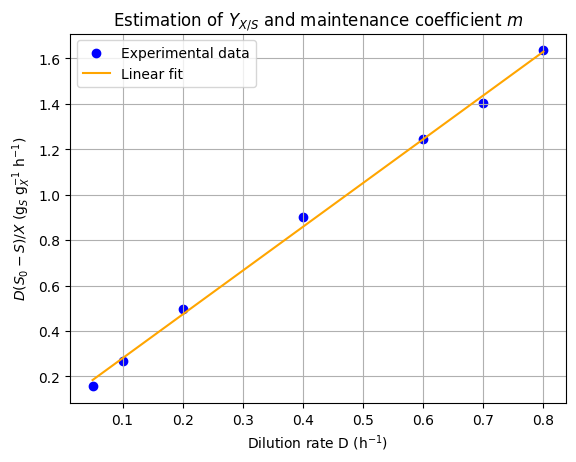

In [26]:
x_maint = D_fit
y_maint = D_fit * (S0 - S_fit) / X[:7]

slope2, intercept2 = np.polyfit(x_maint, y_maint, 1)
Yxs = 1 / slope2
m = intercept2

D_line = np.linspace(min(x_maint), max(x_maint), 100)
y_line = slope2 * D_line + intercept2

print("\nPart (b)")
print(f"Yxs = {Yxs:.4f} gX/gS")
print(f"m   = {m:.4f} gS/(gX*h)")

plt.figure()
plt.scatter(x_maint, y_maint, color = 'blue', label='Experimental data')
plt.plot(D_line, y_line, color = 'orange', label='Linear fit')

plt.xlabel('Dilution rate D (h$^{-1}$)')
plt.ylabel(r'$D(S_0 - S)/X$ (g$_S$ g$_X^{-1}$ h$^{-1}$)')
plt.title('Estimation of $Y_{X/S}$ and maintenance coefficient $m$')

plt.legend()
plt.grid(True)

plt.show()

Exercice 4c) 

At washout, the substrate concentration approaches the feed:

$$
S = S_0
$$

Thus:

$$
D_{\max} = \mu_{\max} \frac{S_0}{K_s + S_0}
$$

The biomass productivity is:

$$
\Pi_X = D \cdot X
$$

Maximizing productivity leads to:

$$
D_{\mathrm{opt}} = \mu_{\max}\left(1 - \sqrt{\frac{K_s}{K_s + S_0}}\right)
$$

In [15]:
D_max = mu_max * S0 / (Ks + S0)
D_opt = mu_max * (1 - np.sqrt(Ks / (Ks + S0)))

print("\nPart (c)")
print(f"D_max = {D_max:.4f} h^-1")
print(f"D_opt = {D_opt:.4f} h^-1")


Part (c)
D_max = 2.1787 h^-1
D_opt = 1.7743 h^-1


Exercice 4d)

From the Monod equation at steady state:

$$
D = \mu_{\max} \frac{S}{K_s + S}
$$

Solving for $S$:

$$
S(D) = \frac{K_s D}{\mu_{\max} - D}
$$

Including maintenance, the substrate balance gives:

$$
D(S_0 - S) = \frac{D X}{Y_{X/S}} + m X
$$

Solving for $X$:

$$
X(D) = \frac{D(S_0 - S(D))}{\frac{D}{Y_{X/S}} + m}
$$

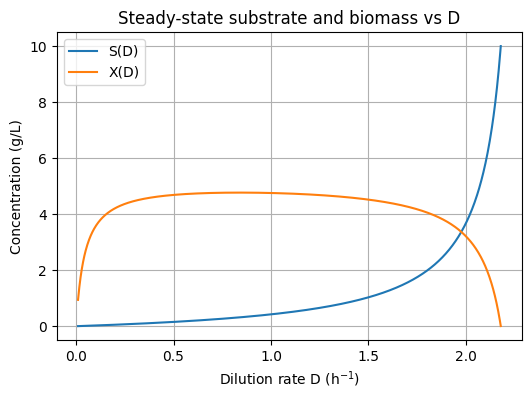

In [28]:
def S_of_D(Dval, mu_max, Ks):
    return Ks * Dval / (mu_max - Dval)

def X_of_D(Dval, mu_max, Ks, Yxs, m, S0):
    Sval = S_of_D(Dval, mu_max, Ks)
    return Dval * (S0 - Sval) / (Dval / Yxs + m)

D_plot = np.linspace(0.01, D_max - 1e-4, 1000)

S_model = S_of_D(D_plot, mu_max, Ks)
X_model = X_of_D(D_plot, mu_max, Ks, Yxs, m, S0)
P_model = D_plot * X_model

plt.figure(figsize=(6, 4))
plt.plot(D_plot, S_model, label='S(D)')
plt.plot(D_plot, X_model, label='X(D)')
plt.xlabel('Dilution rate D (h$^{-1}$)')
plt.ylabel('Concentration (g/L)')
plt.title('Steady-state substrate and biomass vs D')
plt.legend()
plt.grid(True)

Exercice 4e)

The cell productivity is defined as:

$$
\Pi_X(D) = D \cdot X(D)
$$

Using:

$$
S(D) = \frac{K_s D}{\mu_{\max} - D}
$$

and

$$
X(D) = \frac{D(S_0 - S(D))}{\frac{D}{Y_{X/S}} + m}
$$

we compute:

$$
\Pi_X(D) = D \cdot X(D)
$$

The effect of $K_s$ is studied by repeating the calculation for different values of $K_s$.

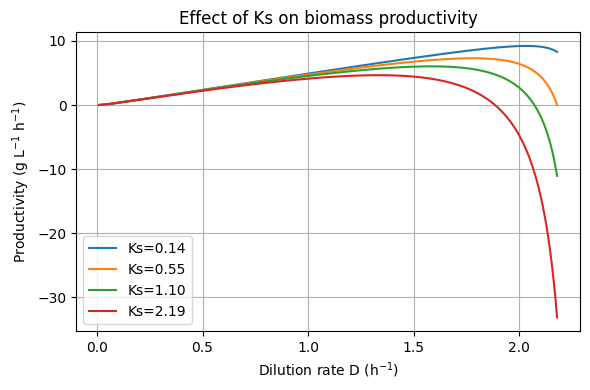

In [29]:
Ks_values = [0.25 * Ks, Ks, 2 * Ks, 4 * Ks]

plt.figure(figsize=(6, 4))
for Ks_i in Ks_values:
    S_tmp = S_of_D(D_plot[D_plot < mu_max], mu_max, Ks_i)
    X_tmp = X_of_D(D_plot[D_plot < mu_max], mu_max, Ks_i, Yxs, m, S0)
    P_tmp = D_plot[D_plot < mu_max] * X_tmp
    plt.plot(D_plot[D_plot < mu_max], P_tmp, label=f'Ks={Ks_i:.2f}')
plt.xlabel('Dilution rate D (h$^{-1}$)')
plt.ylabel('Productivity (g L$^{-1}$ h$^{-1}$)')
plt.title('Effect of Ks on biomass productivity')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Exercice 4f/g)

The maximum productivity is obtained by:

$$
\max_D \left( D \cdot X(D) \right)
$$

The corresponding dilution rate is:

$$
D^* = \arg\max_D \left( D \cdot X(D) \right)
$$


The optimal dilution rate obtained analytically (without maintenance) is:

$$
D_{\mathrm{opt}} = \mu_{\max}\left(1 - \sqrt{\frac{K_s}{K_s + S_0}}\right)
$$

This is compared to the numerical optimum obtained from:

$$
\Pi_X(D) = D \cdot X(D)
$$

including maintenance.


Part (f)
Maximum productivity = 7.3064 g/L/h
At dilution rate     = 1.7792 h^-1


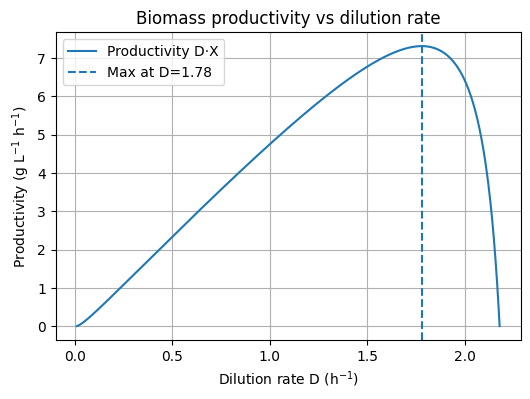

In [33]:
imax = np.argmax(P_model)
D_star = D_plot[imax]
P_max = P_model[imax]

print("\nPart (f)")
print(f"Maximum productivity = {P_max:.4f} g/L/h")
print(f"At dilution rate     = {D_star:.4f} h^-1")

plt.figure(figsize=(6, 4))
plt.plot(D_plot, P_model, label='Productivity D·X')
plt.axvline(D_star, linestyle='--', label=f'Max at D={D_star:.2f}')
plt.xlabel('Dilution rate D (h$^{-1}$)')
plt.ylabel('Productivity (g L$^{-1}$ h$^{-1}$)')
plt.title('Biomass productivity vs dilution rate')
plt.legend()
plt.grid(True)